In [10]:
#importing pandas library
import pandas as pd

In [11]:
#loading dataset
df = pd.read_csv('/content/netflix_titles.zip')

In [12]:
#reading data in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [13]:
#finding out total null values in each column
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [14]:
#data cleaning steps started
#handling missing and null values
cols = ['director', 'cast', 'country', 'date_added', 'rating', 'duration']

df[cols] = df[cols].replace(r'^\s*$', 'NA', regex=True)

In [15]:
df["director"] = df["director"].fillna("Unknown")

In [16]:
df["cast"] = df["cast"].fillna("Unknown cast")

In [17]:
df["country"] = df["country"].fillna("Unknown Country")

In [61]:
df["date_added"] = pd.to_datetime(df["date_added"])

In [20]:
df["rating"] = df["rating"].fillna("Rating Not")

In [21]:
df.drop_duplicates(inplace = True)

In [62]:
#removing extra spaces
text_cols = ["type","title","director","cast","country","rating","listed_in","description"]
for col in text_cols:
  df[col] = df[col].str.strip()

In [63]:
#finding out total number of types of content
af = df['type'].value_counts()

In [64]:
#gives total number of movies and shows in netflix
movies_count = af.iloc[0]
shows_count = af.iloc[1]
print("Netflix contains" + " " + str(movies_count) + " " + "and" + " "+ str(shows_count) +" "+ "TV shows")

Netflix contains 6131 and 2676 TV shows


In [73]:
#prints top ten contributing to netflix content
top_ten_countries = df[df['country'] != 'Unknown Country']['country'].value_counts().head(10)
print(top_ten_countries)
print(top_ten_countries.index[0] + " " + "contributes the highest amount of Netflix content.")


country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64
United States contributes the highest amount of Netflix content.


In [74]:
#prints top 10 highly rated content on netflix
highly_rated = df['rating'].value_counts().head(10)
print(highly_rated)
print(highly_rated.index[0] + " "+ " is the most common content rating on Netflix")
print("Netflix mainly focuses on mature audience content")

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64
TV-MA  is the most common content rating on Netflix
Netflix mainly focuses on mature audience content


In [75]:
#Gives content growth during the years
#prints max and min releases in a year
content_growth = df['release_year'].value_counts(ascending = True).sort_index()
print(content_growth)
print("maximum number of release occured in year" + " " + str(content_growth.idxmax()))
print("minimum number of release occured in year" + " " + str(content_growth.idxmin()))

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64
maximum number of release occured in year 2018
minimum number of release occured in year 1925


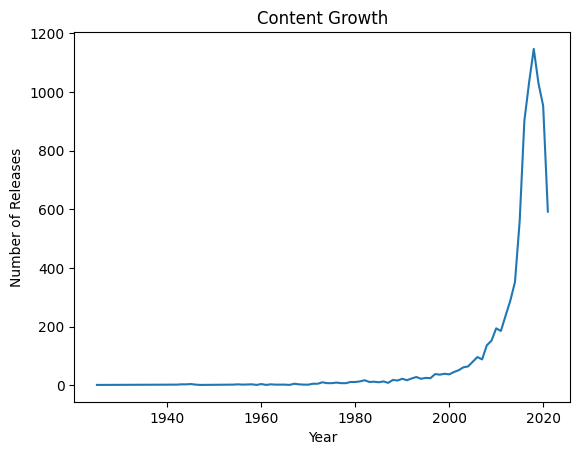

In [76]:
#ploting a line graph with year on x-axis and number of releases on y-axis
import matplotlib.pyplot as plt
plt.plot(content_growth.index,content_growth.values)
plt.title("Content Growth")
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.show()
### Insight
#Netflix content releases increased rapidly after 2015, with peak growth occurring around 2018–2019.

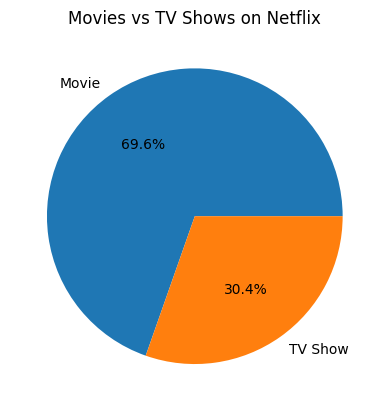

In [77]:
#creating a pie chart for finding out the percentage of movies and TV shows on netflix
import matplotlib.pyplot as plt
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%')
plt.title("Movies vs TV Shows on Netflix")
plt.show()
### Insight
##Movies dominate Netflix content compared to TV Shows, showing that Netflix primarily focuses on movie distribution.

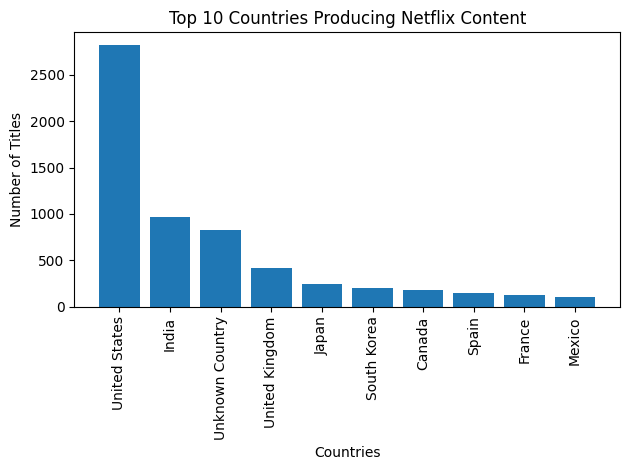

In [72]:
#creating a bar graph by keeping x-axis with countries and y-axis with number of titles
import matplotlib.pyplot as plt

plt.bar(top_ten_countries.index,
        top_ten_countries.values)

plt.title("Top 10 Countries Producing Netflix Content")

plt.xlabel("Countries")

plt.ylabel("Number of Titles")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()
### Insight
##The United States contributes the highest amount of Netflix content, followed by India and the United Kingdom.